In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
import os

print("Current Folder:")
print(os.getcwd())

print("\nFiles in current folder:")
print(os.listdir())

Current Folder:
/Users/azharkhan/Desktop/ECG-Arrhythmia-Detection/notebooks

Files in current folder:
['01_EDA_and_Data_Preprocessing.ipynb']


In [4]:
import os

for root, dirs, files in os.walk("."):
    if "100.csv" in files:
        print("Found:", os.path.join(root, "100.csv"))

In [5]:
import os

print(os.getcwd())

/Users/azharkhan/Desktop/ECG-Arrhythmia-Detection/notebooks


In [6]:
# Load one ECG record

record = 100

ecg = pd.read_csv(f"../dataset/{record}.csv")

# Clean column names
ecg.columns = (
    ecg.columns
    .str.replace("'", "", regex=False)
    .str.strip()
)

print("Shape :", ecg.shape)
print("\nColumns :")
print(ecg.columns.tolist())

ecg.head()

Shape : (650000, 3)

Columns :
['sample #', 'MLII', 'V5']


,sample #,MLII,V5
0,0,995,1011
1,1,995,1011
2,2,995,1011
3,3,995,1011
4,4,995,1011


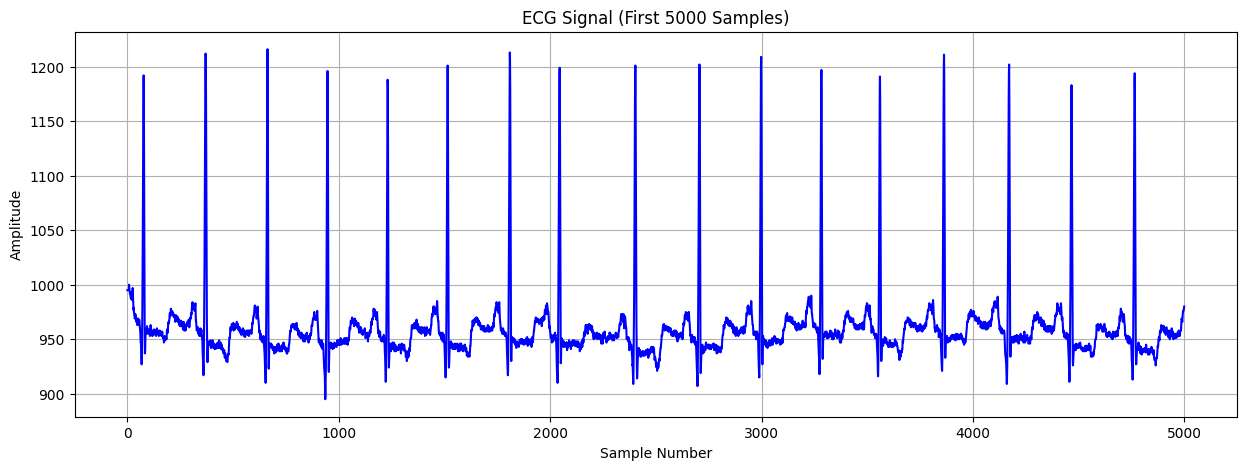

In [7]:
plt.figure(figsize=(15,5))

plt.plot(ecg["MLII"][:5000], color="blue")

plt.title("ECG Signal (First 5000 Samples)")
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")

plt.grid(True)

plt.show()

In [8]:
# ============================
# Load Annotation File
# ============================

ann = pd.read_csv(
    "../dataset/100annotations.txt",
    sep=r"\s+",
    header=None,
    skiprows=1,
    engine="python"
)

print("Annotation Shape :", ann.shape)

ann.head()

Annotation Shape : (2274, 7)


,0,1,2,3,4,5,6
0,0:00.050,18,+,0,0,0,(N
1,0:00.214,77,N,0,0,0,None
2,0:01.028,370,N,0,0,0,None
3,0:01.839,662,N,0,0,0,None
4,0:02.628,946,N,0,0,0,None


In [9]:
# ============================
# Rename Annotation Columns
# ============================

ann.columns = [
    "Time",
    "Sample",
    "Type",
    "Sub",
    "Chan",
    "Num",
    "Aux"
]

print(ann.columns.tolist())

ann.head()

['Time', 'Sample', 'Type', 'Sub', 'Chan', 'Num', 'Aux']


,Time,Sample,Type,Sub,Chan,Num,Aux
0,0:00.050,18,+,0,0,0,(N
1,0:00.214,77,N,0,0,0,None
2,0:01.028,370,N,0,0,0,None
3,0:01.839,662,N,0,0,0,None
4,0:02.628,946,N,0,0,0,None


In [10]:
# ============================
# Keep Required Beat Types
# ============================

ann = ann[ann["Type"].isin(["N", "A", "V"])]

print("Total Beats :", len(ann))
print()

print(ann["Type"].value_counts())

Total Beats : 2273

Type
N    2239
A      33
V       1
Name: count, dtype: int64


In [11]:
# ============================
# Function to Process One ECG Record
# ============================

def process_record(record):

    # Load ECG
    ecg = pd.read_csv(f"../dataset/{record}.csv")

    ecg.columns = (
        ecg.columns
        .str.replace("'", "", regex=False)
        .str.strip()
    )

    # Select ECG Lead
    if "MLII" in ecg.columns:
        lead = "MLII"
    elif "V5" in ecg.columns:
        lead = "V5"
    else:
        raise ValueError(f"No ECG Lead Found in Record {record}")

    # Load Annotation File
    ann = pd.read_csv(
        f"../dataset/{record}annotations.txt",
        sep=r"\s+",
        header=None,
        skiprows=1,
        engine="python"
    )

    ann = ann.iloc[:, :7]

    ann.columns = [
        "Time",
        "Sample",
        "Type",
        "Sub",
        "Chan",
        "Num",
        "Aux"
    ]

    # Keep only required beat types
    ann = ann[ann["Type"].isin(["N", "A", "V"])]

    X = []
    y = []

    for _, row in ann.iterrows():

        sample = int(row["Sample"])

        # Ignore beats near signal boundaries
        if sample < 100 or sample + 100 >= len(ecg):
            continue

        beat = ecg[lead].iloc[sample-100:sample+100].values

        if len(beat) == 200:
            X.append(beat)
            y.append(row["Type"])

    return np.array(X), np.array(y)

In [12]:
X100, y100 = process_record(100)

print("X Shape :", X100.shape)
print()

print(pd.Series(y100).value_counts())

X Shape : (2271, 200)

N    2237
A      33
V       1
Name: count, dtype: int64


In [13]:
# ============================
# MIT-BIH Records
# ============================

records = [
    100,101,103,105,106,107,108,109,
    111,112,113,114,115,116,117,118,119,
    121,122,123,124,

    200,201,202,203,205,207,208,209,
    210,212,213,214,215,217,219,
    220,221,222,223,

    228,230,231,232,233,234
]

print("Total Records :", len(records))

Total Records : 46


In [14]:
# ============================
# Process All Records
# ============================

X_all = []
y_all = []

for record in records:

    print(f"Processing Record {record}...")

    try:
        X, y = process_record(record)

        if len(X) > 0:
            X_all.extend(X)
            y_all.extend(y)

    except Exception as e:
        print(f"Skipped Record {record} -> {e}")

X_all = np.array(X_all)
y_all = np.array(y_all)

print("\nDone!")

Processing Record 100...
Processing Record 101...
Processing Record 103...
Processing Record 105...
Processing Record 106...
Skipped Record 106 -> Expected 6 fields in line 3, saw 7. Error could possibly be due to quotes being ignored when a multi-char delimiter is used.
Processing Record 107...
Processing Record 108...
Processing Record 109...
Processing Record 111...
Processing Record 112...
Processing Record 113...
Processing Record 114...
Processing Record 115...
Processing Record 116...
Processing Record 117...
Processing Record 118...
Processing Record 119...
Processing Record 121...
Processing Record 122...
Processing Record 123...
Processing Record 124...
Processing Record 200...
Processing Record 201...
Processing Record 202...
Processing Record 203...
Processing Record 205...
Processing Record 207...
Processing Record 208...
Processing Record 209...
Processing Record 210...
Processing Record 212...
Processing Record 213...
Processing Record 214...
Processing Record 215...
Pro

In [15]:
print("X_all Shape :", X_all.shape)
print()

print(pd.Series(y_all).value_counts())

X_all Shape : (82408, 200)

N    73259
V     6603
A     2546
Name: count, dtype: int64


In [16]:
for r in [100, 106, 214, 228, 231]:
    try:
        X, y = process_record(r)
        print(f"Record {r}: {len(y)} beats")
        print(pd.Series(y).value_counts())
        print("-" * 40)
    except Exception as e:
        print(f"Record {r}: ERROR -> {e}")

Record 100: 2271 beats
N    2237
A      33
V       1
Name: count, dtype: int64
----------------------------------------
Record 106: ERROR -> Expected 6 fields in line 3, saw 7. Error could possibly be due to quotes being ignored when a multi-char delimiter is used.
Record 214: 256 beats
V    256
Name: count, dtype: int64
----------------------------------------
Record 228: 2053 beats
N    1688
V     362
A       3
Name: count, dtype: int64
----------------------------------------
Record 231: 317 beats
N    314
V      2
A      1
Name: count, dtype: int64
----------------------------------------


In [17]:
with open("../dataset/106annotations.txt", "r") as f:
    for i in range(10):
        print(f.readline().rstrip())

      Time   Sample #  Type  Sub Chan  Num	Aux
    0:00.231       83     ~    2    0    0
    0:00.636      229     +    0    0    0	(N
    0:00.975      351     N    0    0    0
    0:02.011      724     N    0    0    0
    0:03.017     1086     N    0    0    0
    0:04.022     1448     N    0    0    0
    0:05.081     1829     N    0    0    0
    0:06.103     2197     N    0    0    0
    0:07.142     2571     N    0    0    0


In [18]:
records = [
100,101,103,105,
107,108,109,
111,112,113,114,115,116,117,118,119,
121,122,123,124,
200,201,202,203,205,207,208,209,
210,212,213,214,215,217,219,
220,221,222,223,
228,230,231,232,233,234
]

In [19]:
X_all = np.array(X_all)
y_all = np.array(y_all)

print(X_all.shape)
print(pd.Series(y_all).value_counts())

(82408, 200)
N    73259
V     6603
A     2546
Name: count, dtype: int64


In [20]:
# ============================
# Dataset Information
# ============================

print("Dataset Shape :", ecg.shape)
print("\nColumn Names:")
print(ecg.columns.tolist())

print("\nDataset Info:")
ecg.info()

Dataset Shape : (650000, 3)

Column Names:
['sample #', 'MLII', 'V5']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650000 entries, 0 to 649999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   sample #  650000 non-null  int64
 1   MLII      650000 non-null  int64
 2   V5        650000 non-null  int64
dtypes: int64(3)
memory usage: 14.9 MB


In [21]:
# ============================
# Missing Values
# ============================

print(ecg.isnull().sum())

sample #    0
MLII        0
V5          0
dtype: int64


In [22]:
# ============================
# Statistical Summary
# ============================

ecg.describe()

,sample #,MLII,V5
count,650000.000000,650000.000000,650000.000000
mean,324999.500000,962.740205,985.793114
std,187638.981824,38.639938,29.642668
min,0.000000,481.000000,531.000000
25%,162499.750000,946.000000,971.000000
50%,324999.500000,957.000000,983.000000
75%,487499.250000,970.000000,995.000000
max,649999.000000,1311.000000,1269.000000


In [23]:
# ============================
# Annotation Distribution
# ============================

print(ann["Type"].value_counts())

Type
N    2239
A      33
V       1
Name: count, dtype: int64


In [24]:
# ============================
# Extract One Beat of Each Class
# ============================

normal_beat = X100[y100 == "N"][0]
atrial_beat = X100[y100 == "A"][0]
ventricular_beat = X100[y100 == "V"][0]

print("Normal Beat Shape :", normal_beat.shape)
print("Atrial Beat Shape :", atrial_beat.shape)
print("Ventricular Beat Shape :", ventricular_beat.shape)

Normal Beat Shape : (200,)
Atrial Beat Shape : (200,)
Ventricular Beat Shape : (200,)


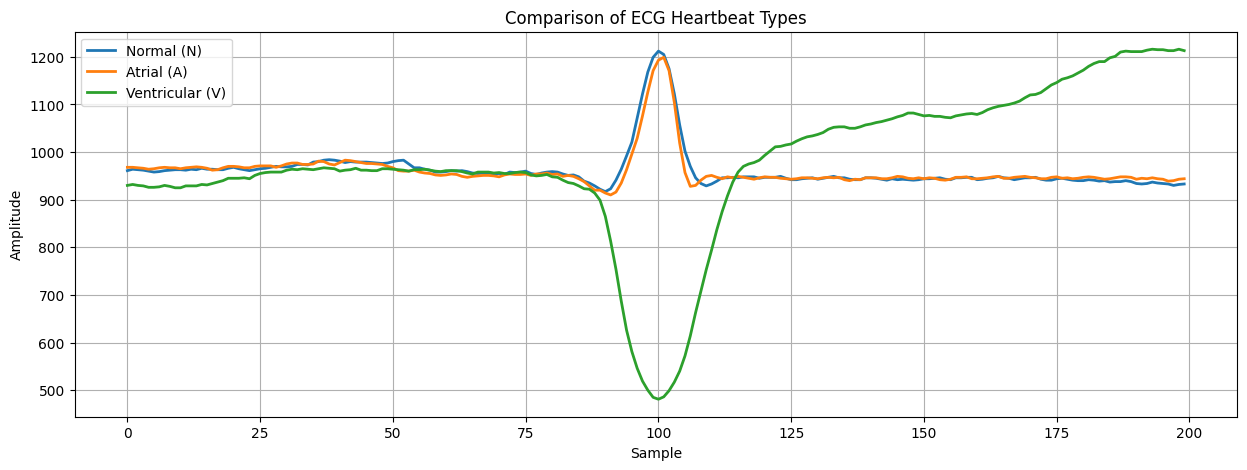

In [25]:
# ============================
# Compare Heartbeat Types
# ============================

plt.figure(figsize=(15,5))

plt.plot(normal_beat, label="Normal (N)", linewidth=2)
plt.plot(atrial_beat, label="Atrial (A)", linewidth=2)
plt.plot(ventricular_beat, label="Ventricular (V)", linewidth=2)

plt.title("Comparison of ECG Heartbeat Types")

plt.xlabel("Sample")

plt.ylabel("Amplitude")

plt.legend()

plt.grid(True)

plt.show()

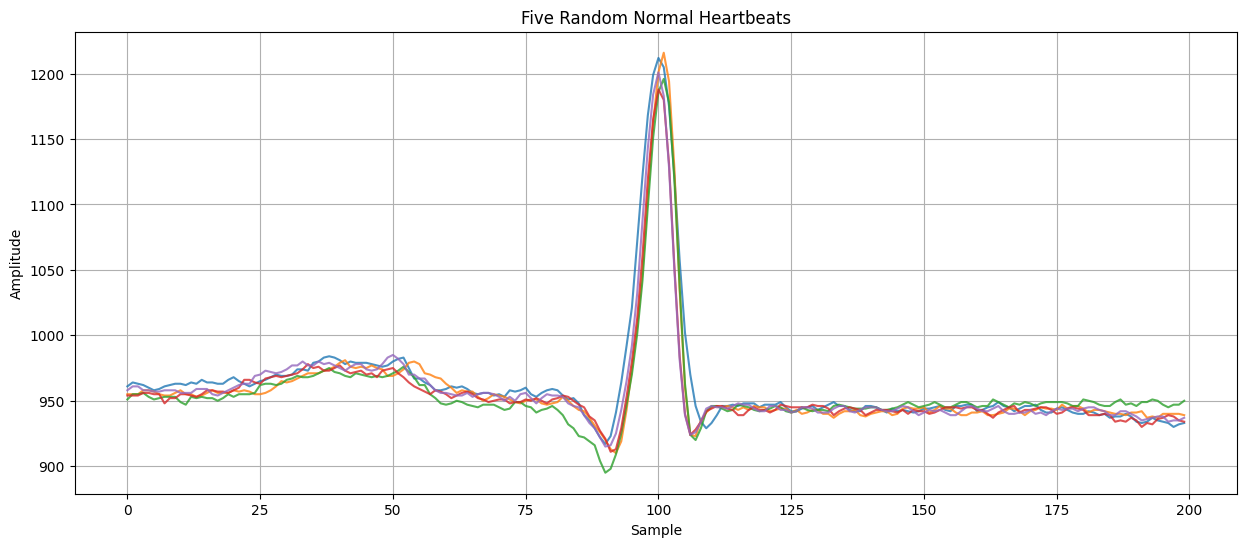

In [26]:
# ============================
# Random Normal Beats
# ============================

plt.figure(figsize=(15,6))

for i in range(5):
    plt.plot(X100[y100=="N"][i], alpha=0.8)

plt.title("Five Random Normal Heartbeats")

plt.xlabel("Sample")

plt.ylabel("Amplitude")

plt.grid(True)

plt.show()

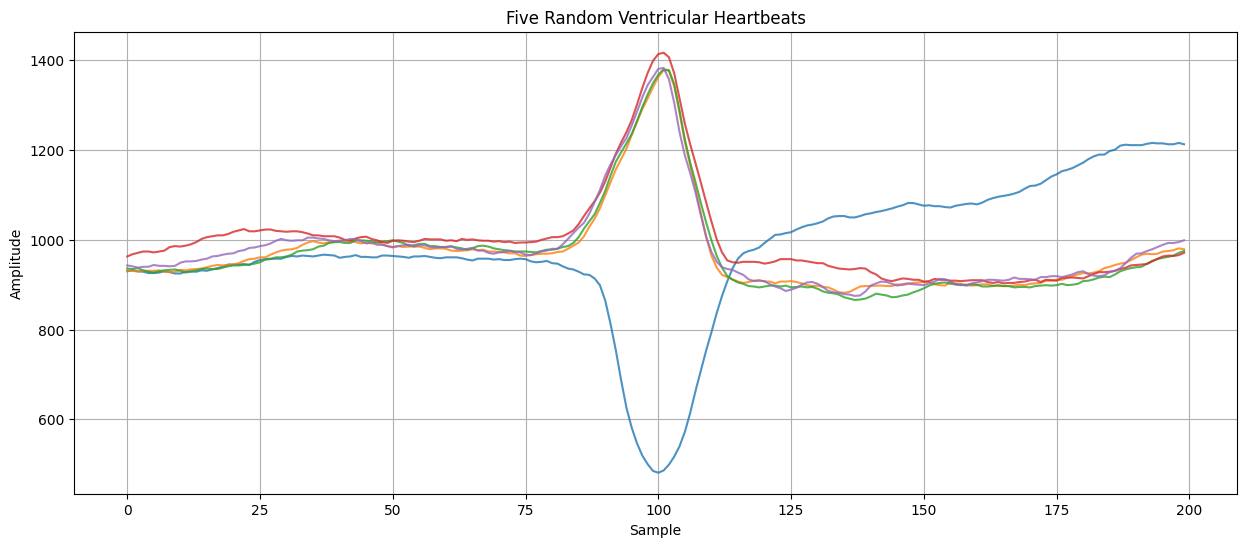

In [27]:
# ============================
# Random Ventricular Beats
# ============================

plt.figure(figsize=(15,6))

v_beats = X_all[y_all=="V"]

for i in range(5):
    plt.plot(v_beats[i], alpha=0.8)

plt.title("Five Random Ventricular Heartbeats")

plt.xlabel("Sample")

plt.ylabel("Amplitude")

plt.grid(True)

plt.show()

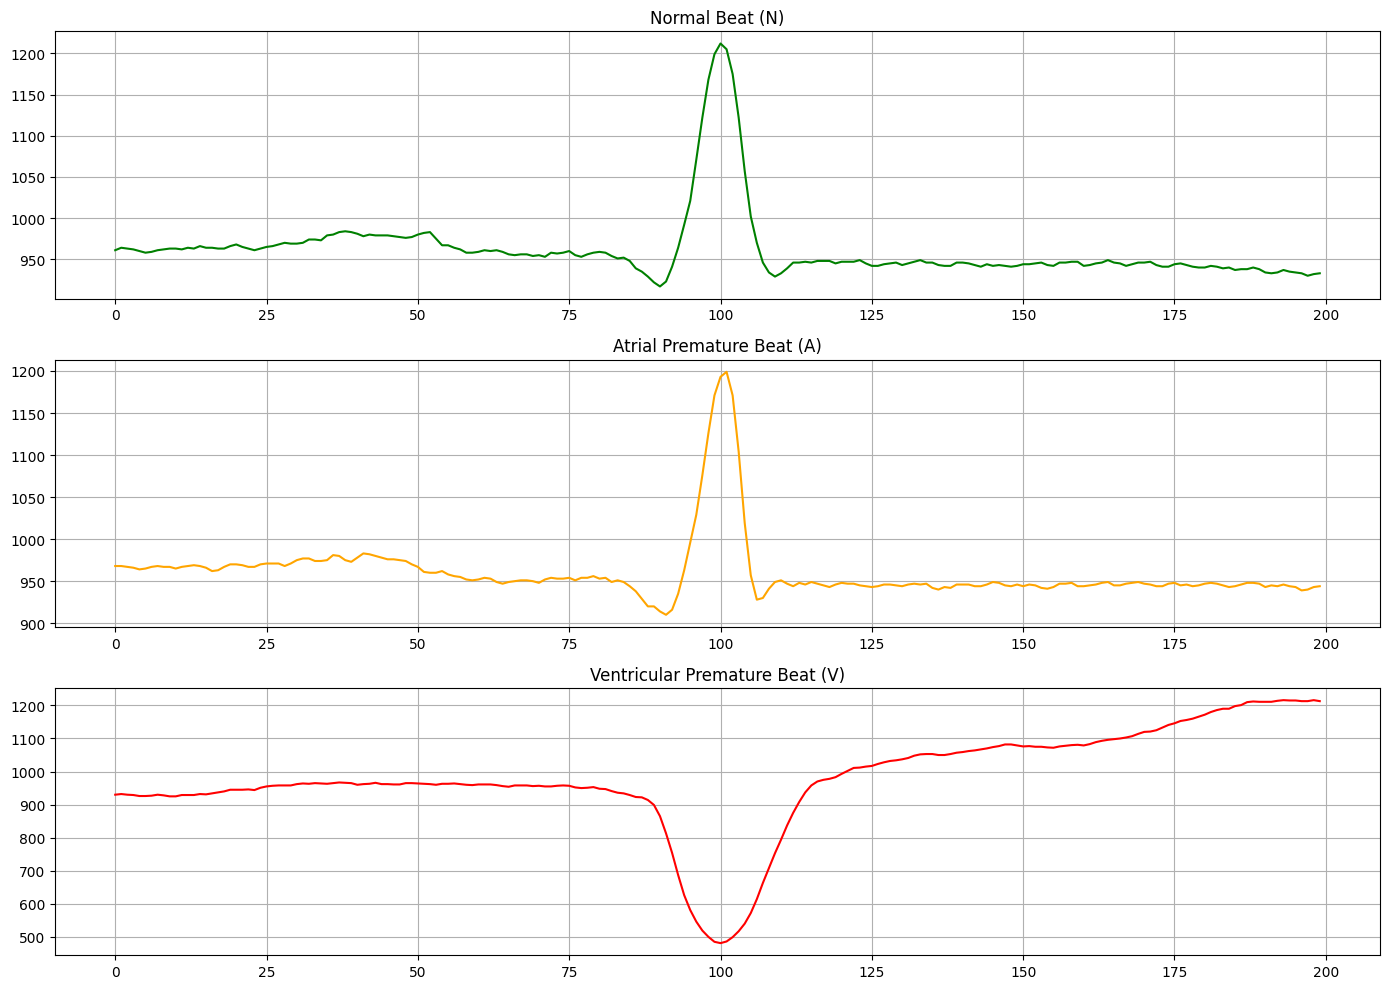

In [28]:
# ============================
# Individual Heartbeat Visualization
# ============================

fig, ax = plt.subplots(3, 1, figsize=(14,10))

ax[0].plot(normal_beat, color="green")
ax[0].set_title("Normal Beat (N)")
ax[0].grid(True)

ax[1].plot(atrial_beat, color="orange")
ax[1].set_title("Atrial Premature Beat (A)")
ax[1].grid(True)

ax[2].plot(ventricular_beat, color="red")
ax[2].set_title("Ventricular Premature Beat (V)")
ax[2].grid(True)

plt.tight_layout()
plt.show()

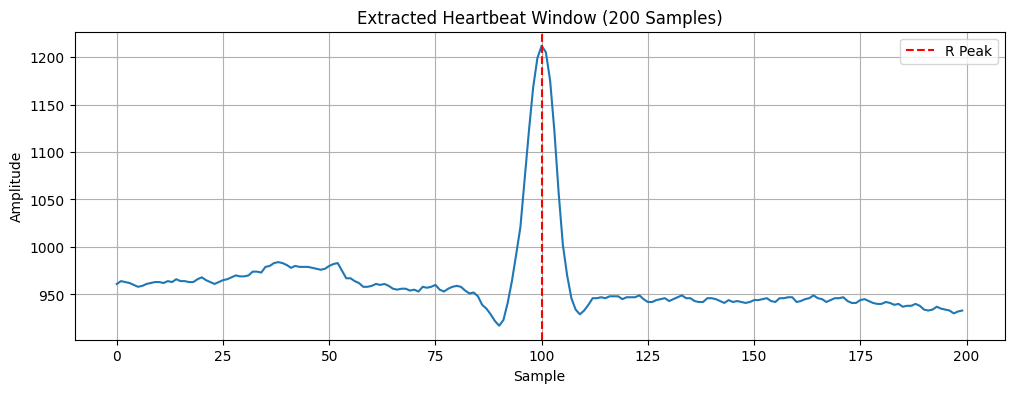

In [29]:
plt.figure(figsize=(12,4))

plt.plot(normal_beat)

plt.axvline(100, color="red", linestyle="--", label="R Peak")

plt.title("Extracted Heartbeat Window (200 Samples)")

plt.xlabel("Sample")

plt.ylabel("Amplitude")

plt.legend()

plt.grid(True)

plt.show()

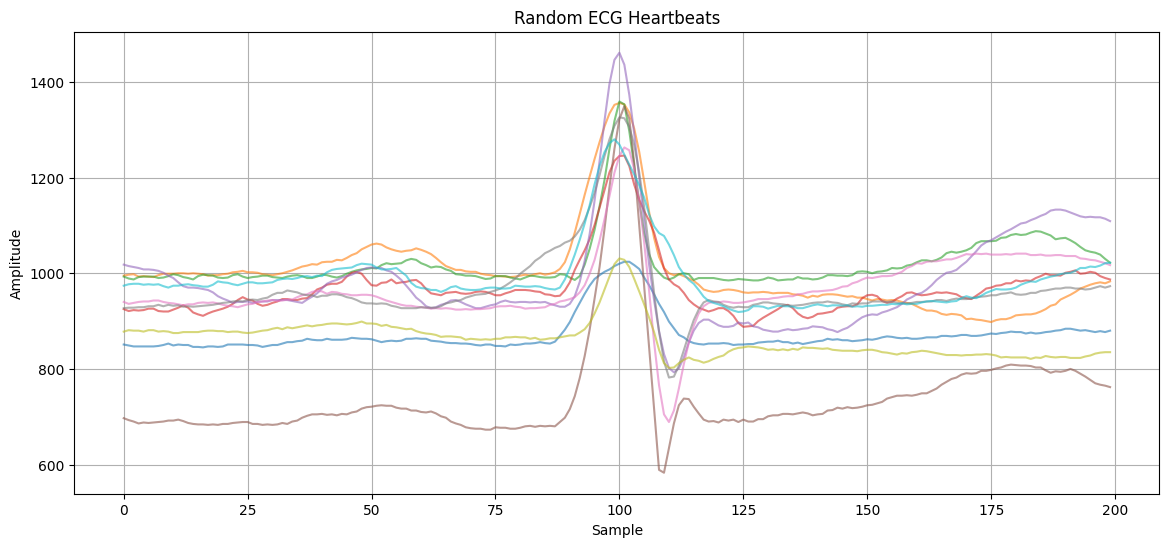

In [30]:
plt.figure(figsize=(14,6))

for i in range(10):
    idx = np.random.randint(0, len(X_all))
    plt.plot(X_all[idx], alpha=0.6)

plt.title("Random ECG Heartbeats")

plt.xlabel("Sample")

plt.ylabel("Amplitude")

plt.grid(True)

plt.show()

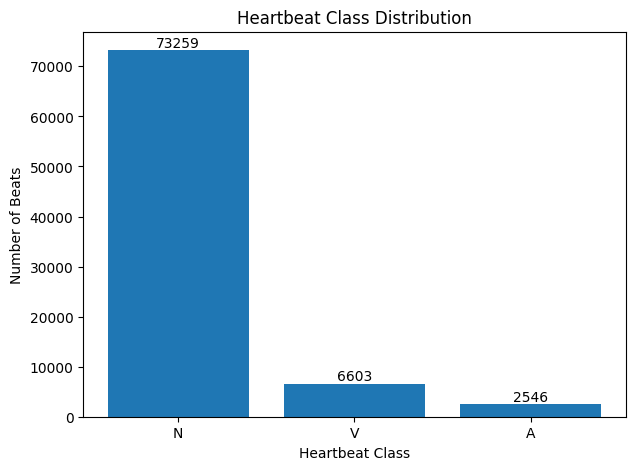

In [31]:
counts = pd.Series(y_all).value_counts()

plt.figure(figsize=(7,5))

bars = plt.bar(counts.index, counts.values)

plt.title("Heartbeat Class Distribution")

plt.xlabel("Heartbeat Class")

plt.ylabel("Number of Beats")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        int(y),
        ha="center",
        va="bottom"
    )

plt.show()

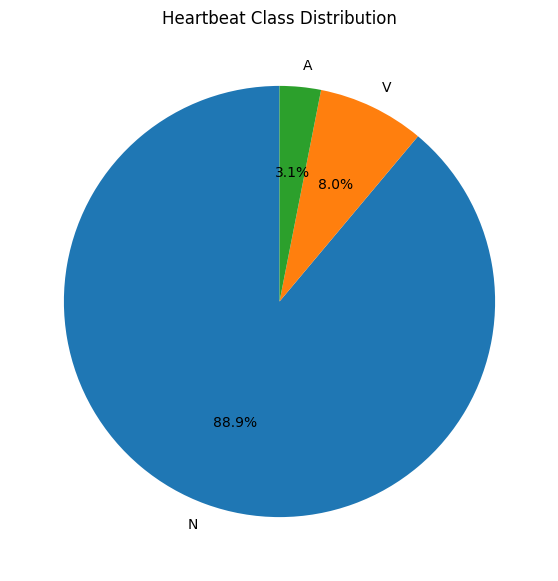

In [32]:
plt.figure(figsize=(7,7))

plt.pie(
    counts.values,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Heartbeat Class Distribution")

plt.show()

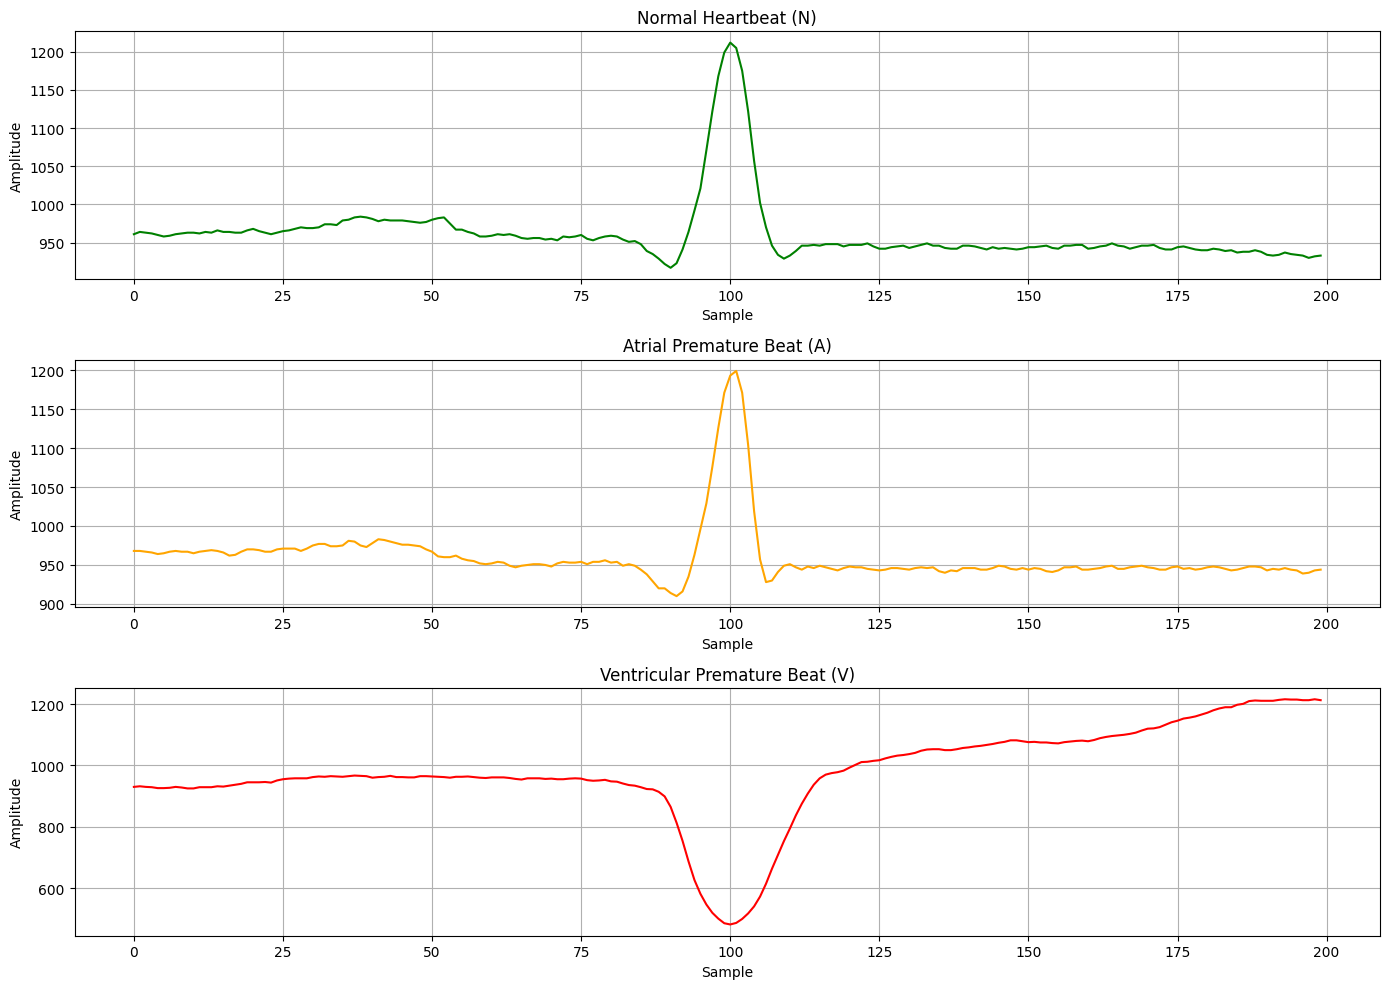

In [33]:
# ============================
# Individual Heartbeat Visualization
# ============================

fig, ax = plt.subplots(3, 1, figsize=(14,10))

# Normal Beat
ax[0].plot(normal_beat, color="green")
ax[0].set_title("Normal Heartbeat (N)")
ax[0].set_xlabel("Sample")
ax[0].set_ylabel("Amplitude")
ax[0].grid(True)

# Atrial Beat
ax[1].plot(atrial_beat, color="orange")
ax[1].set_title("Atrial Premature Beat (A)")
ax[1].set_xlabel("Sample")
ax[1].set_ylabel("Amplitude")
ax[1].grid(True)

# Ventricular Beat
ax[2].plot(ventricular_beat, color="red")
ax[2].set_title("Ventricular Premature Beat (V)")
ax[2].set_xlabel("Sample")
ax[2].set_ylabel("Amplitude")
ax[2].grid(True)

plt.tight_layout()
plt.show()

In [36]:
import numpy as np
import scipy

print("NumPy :", np.__version__)
print("SciPy :", scipy.__version__)

NumPy : 1.24.3
SciPy : 1.17.1


In [40]:
import sys
print(sys.executable)

/usr/local/bin/python3


In [41]:
import sys
print(sys.executable)

/usr/local/bin/python3


In [42]:
import sys
print(sys.executable)

/usr/local/bin/python3


In [43]:
import numpy
print(numpy.__version__)

import scipy
print(scipy.__version__)

import sklearn
print(sklearn.__version__)

1.24.3
1.17.1
1.3.2


In [44]:
from sklearn.preprocessing import LabelEncoder

print("LabelEncoder OK")

LabelEncoder OK


In [45]:
from sklearn.preprocessing import StandardScaler

print("StandardScaler OK")

StandardScaler OK


In [46]:
from sklearn.model_selection import train_test_split

print("train_test_split OK")

train_test_split OK


In [47]:
# ============================
# Label Encoding
# ============================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y_all)

print("Classes:")
print(label_encoder.classes_)

print("\nEncoded Label Distribution:")
print(pd.Series(y_encoded).value_counts())

Classes:
['A' 'N' 'V']

Encoded Label Distribution:
1    73259
2     6603
0     2546
Name: count, dtype: int64


In [48]:
# ============================
# Standard Scaling
# ============================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_all)

print("Scaled Dataset Shape:", X_scaled.shape)

Scaled Dataset Shape: (82408, 200)


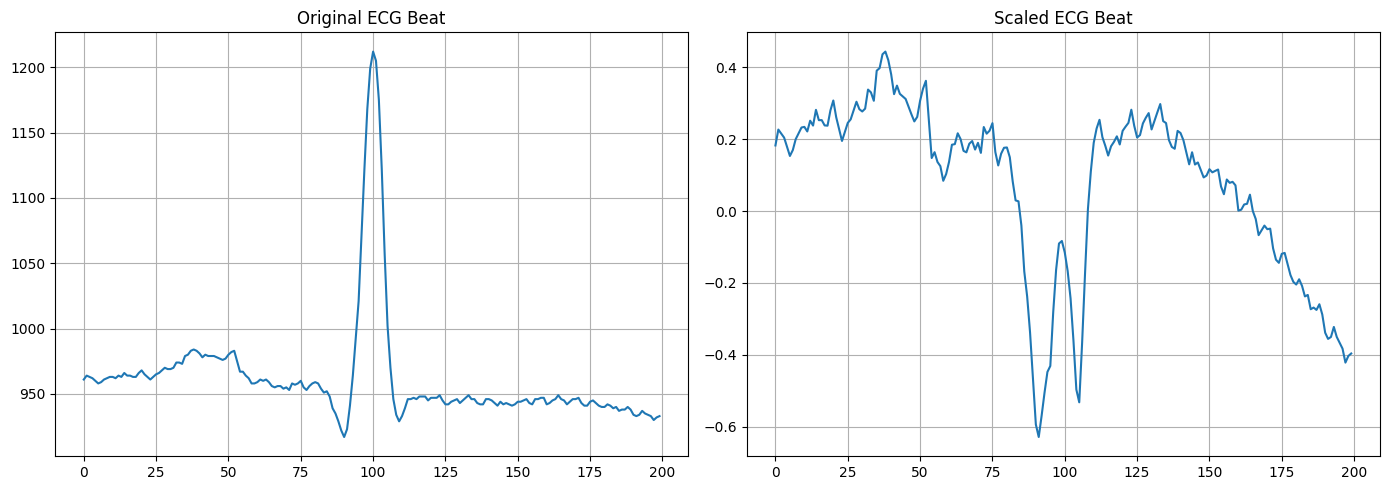

In [49]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(X_all[0])
plt.title("Original ECG Beat")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(X_scaled[0])
plt.title("Scaled ECG Beat")
plt.grid(True)

plt.tight_layout()
plt.show()

In [50]:
# ============================
# Principal Component Analysis (PCA)
# ============================

from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

print("Original Shape :", X_scaled.shape)
print("PCA Shape      :", X_pca.shape)

Original Shape : (82408, 200)
PCA Shape      : (82408, 2)


In [51]:
# ============================
# Explained Variance
# ============================

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Explained Variance:")
print(round(sum(pca.explained_variance_ratio_) * 100, 2), "%")

Explained Variance Ratio:
[0.69490423 0.14454674]

Total Explained Variance:
83.95 %


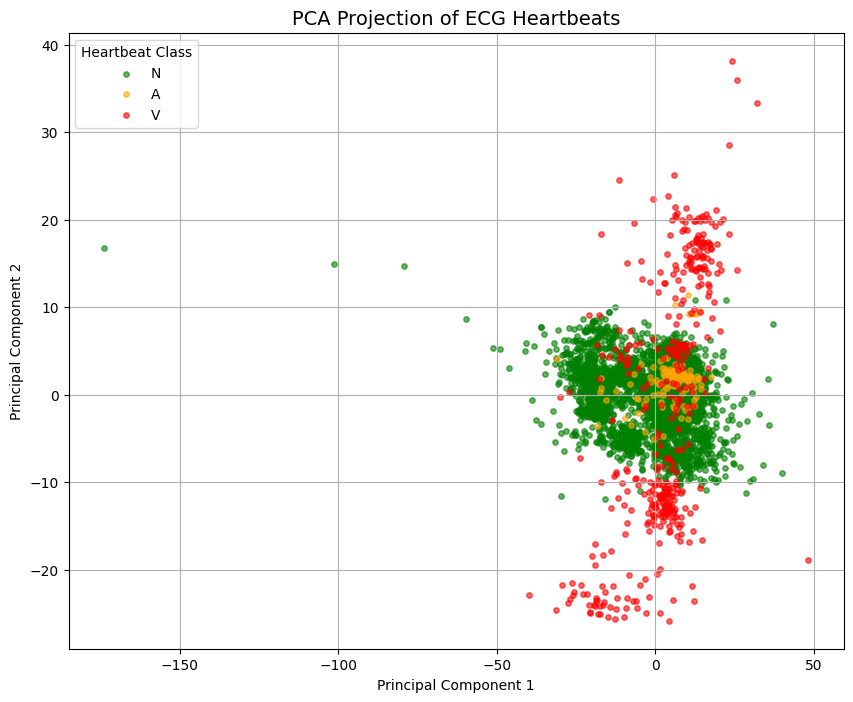

In [52]:
# ============================
# PCA Scatter Plot
# ============================

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

idx = np.random.choice(len(X_pca), 5000, replace=False)

X_plot = X_pca[idx]
y_plot = y_all[idx]

plt.figure(figsize=(10,8))

colors = {
    "N": "green",
    "A": "orange",
    "V": "red"
}

for cls in ["N", "A", "V"]:
    mask = (y_plot == cls)

    plt.scatter(
        X_plot[mask, 0],
        X_plot[mask, 1],
        s=15,
        alpha=0.6,
        label=cls,
        c=colors[cls]
    )

plt.title("PCA Projection of ECG Heartbeats", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Heartbeat Class")
plt.grid(True)

plt.show()

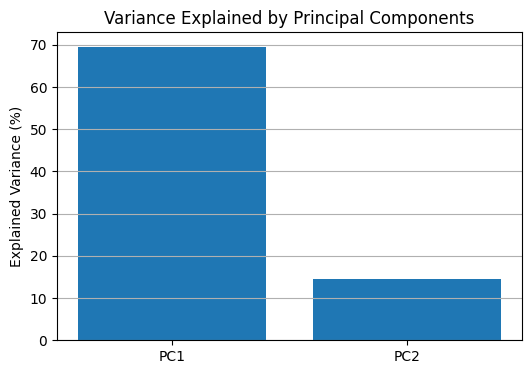

In [53]:
explained = pca.explained_variance_ratio_

plt.figure(figsize=(6,4))

plt.bar(
    ["PC1", "PC2"],
    explained * 100
)

plt.ylabel("Explained Variance (%)")
plt.title("Variance Explained by Principal Components")

plt.grid(axis="y")

plt.show()

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (65926, 200)
Testing Shape  : (16482, 200)


In [55]:
np.save("../dataset/X_train.npy", X_train)
np.save("../dataset/X_test.npy", X_test)

np.save("../dataset/y_train.npy", y_train)
np.save("../dataset/y_test.npy", y_test)

print("✅ Dataset Saved Successfully")

✅ Dataset Saved Successfully


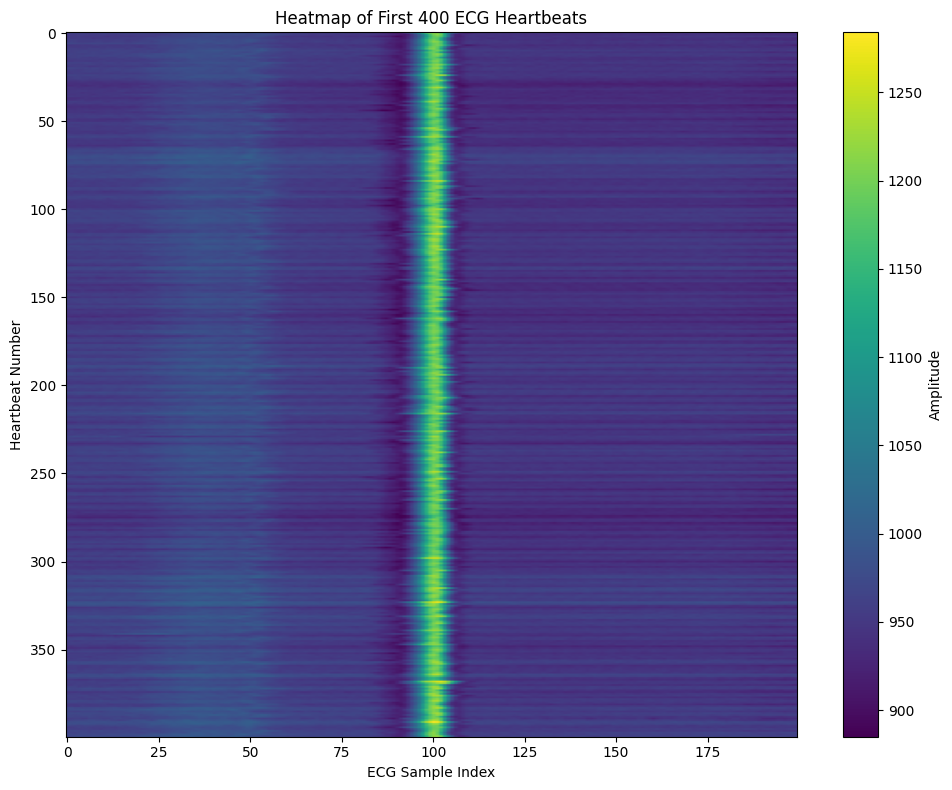

In [56]:
# =====================================================
# ECG Heartbeat Heatmap
# =====================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.imshow(
    X_all[:400],
    aspect="auto",
    cmap="viridis"
)

plt.colorbar(label="Amplitude")

plt.xlabel("ECG Sample Index")
plt.ylabel("Heartbeat Number")

plt.title("Heatmap of First 400 ECG Heartbeats")

plt.tight_layout()

plt.savefig("../images/ecg_heatmap.png", dpi=300)

plt.show()

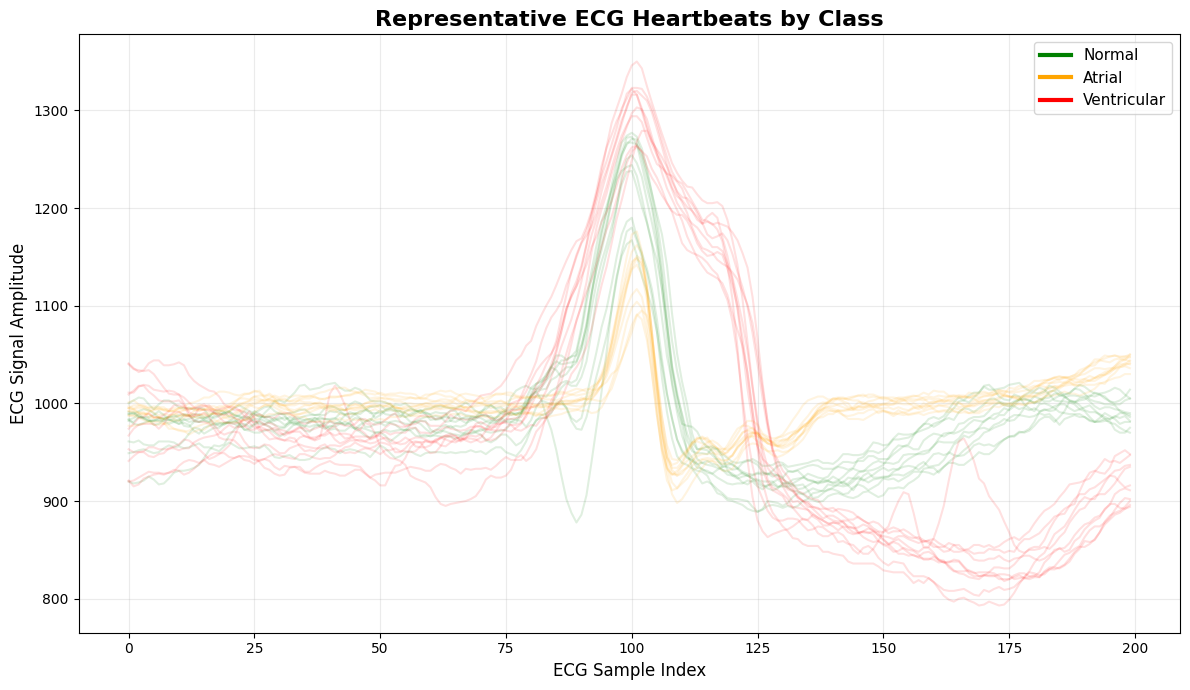

In [ ]:
# =====================================================
# Representative ECG Heartbeats by Class
# =====================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.figure(figsize=(12,7))

colors = {
    "N": "green",
    "A": "orange",
    "V": "red"
}

labels = {
    "N": "Normal",
    "A": "Atrial",
    "V": "Ventricular"
}

for cls in ["N", "A", "V"]:

    idx = np.where(y_all == cls)[0]

    # First 10 representative beats
    center = len(idx) // 2
    idx = idx[center:center+10]

    for i in idx:

        plt.plot(
            X_all[i],
            color=colors[cls],
            alpha=0.12,
            linewidth=1.5
        )

legend = [
    Line2D([0], [0], color="green", lw=3, label="Normal"),
    Line2D([0], [0], color="orange", lw=3, label="Atrial"),
    Line2D([0], [0], color="red", lw=3, label="Ventricular")
]

plt.legend(handles=legend, fontsize=11)

plt.title(
    "Representative ECG Heartbeats by Class",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("ECG Sample Index", fontsize=12)

plt.ylabel("ECG Signal Amplitude", fontsize=12)

plt.grid(alpha=0.15)

plt.tight_layout()

plt.savefig(
    "../images/ecg_overlay.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

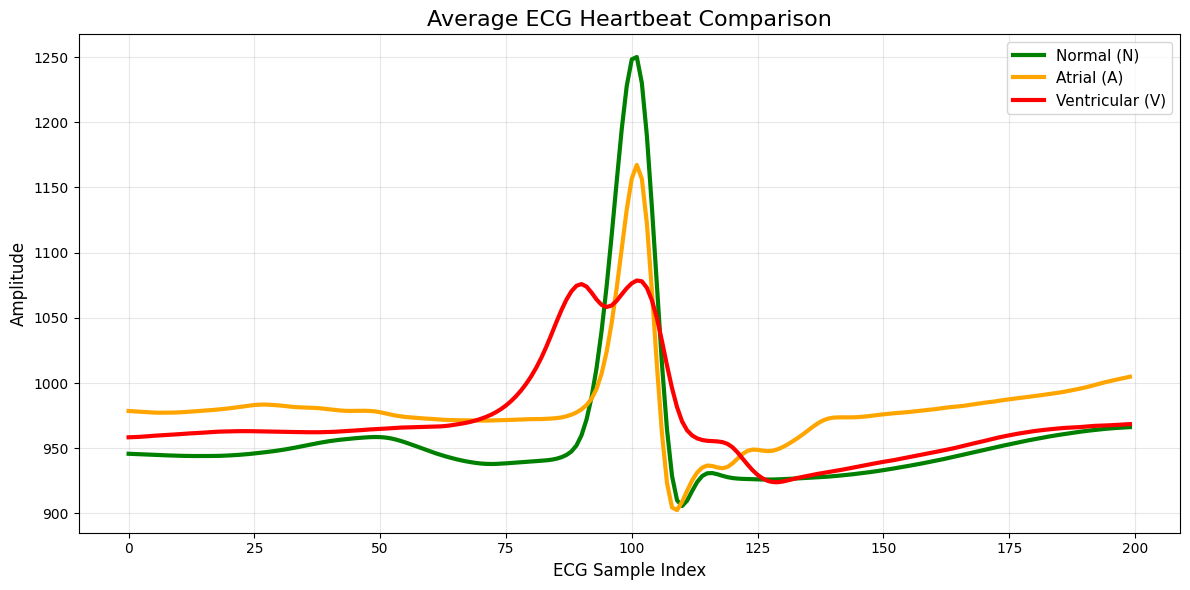

In [59]:
# =====================================================
# Average Heartbeat Comparison
# =====================================================

import numpy as np
import matplotlib.pyplot as plt

# Calculate Mean ECG Beat of Each Class
normal_mean = X_all[y_all == "N"].mean(axis=0)
atrial_mean = X_all[y_all == "A"].mean(axis=0)
ventricular_mean = X_all[y_all == "V"].mean(axis=0)

# Plot
plt.figure(figsize=(12,6))

plt.plot(normal_mean,
         color="green",
         linewidth=3,
         label="Normal (N)")

plt.plot(atrial_mean,
         color="orange",
         linewidth=3,
         label="Atrial (A)")

plt.plot(ventricular_mean,
         color="red",
         linewidth=3,
         label="Ventricular (V)")

plt.title("Average ECG Heartbeat Comparison", fontsize=16)

plt.xlabel("ECG Sample Index", fontsize=12)

plt.ylabel("Amplitude", fontsize=12)

plt.grid(alpha=0.3)

plt.legend(fontsize=11)

plt.tight_layout()

plt.savefig("../images/average_heartbeat_comparison.png",
            dpi=300,
            bbox_inches="tight")

plt.show()